# Best PPO Showcase

Este notebook assume que ja tens pelo menos uma run `PPO` em `outputs/`. O objetivo e carregar o melhor checkpoint, resumir a run e mostrar uma avaliacao final mais estavel.


## Passo 1: Setup


In [1]:
from __future__ import annotations

import json
import statistics
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import torch

ROOT = Path.cwd().resolve()
for candidate in [ROOT, *ROOT.parents]:
    if (candidate / 'connect4_rl').exists():
        ROOT = candidate
        break
else:
    raise RuntimeError('Nao encontrei a raiz do repositorio com a pasta connect4_rl.')
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from connect4_rl.agents.baselines import MinimaxAgent, RandomAgent, StrongHeuristicAgent, WeakHeuristicAgent
from connect4_rl.experiments import build_agent_from_run, find_best_run
from connect4_rl.experiments.checkpoints import build_agent_from_checkpoint
from connect4_rl.experiments.ppo_training import evaluate_match_summary


## Passo 2: Escolher a run


In [2]:
OUTPUTS = ROOT / 'notebooks' / 'ppo' / 'outputs'
OUTPUTS.mkdir(parents=True, exist_ok=True)
NOTEBOOK_DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
preferred_run_name = 'ppo_tutorial_full_final_push_midlevel_bc_seed_42'
preferred_metrics = OUTPUTS / preferred_run_name / 'metrics_final.json'
if preferred_metrics.exists():
    metrics_data = json.loads(preferred_metrics.read_text(encoding='utf-8'))
    focus_checkpoint_path = metrics_data.get('best_vs_strong_checkpoint_path') or metrics_data.get('best_checkpoint_path')
    agent = build_agent_from_checkpoint('ppo', ROOT / focus_checkpoint_path, dict(metrics_data.get('config', {})), device=NOTEBOOK_DEVICE)
    run_name = preferred_run_name
else:
    best_run = find_best_run(OUTPUTS, 'ppo')
    if best_run is None:
        raise RuntimeError('Nao encontrei runs PPO em outputs/. Corre primeiro o notebook 04.')

    metrics_data = dict(best_run.data)
    agent = build_agent_from_run(best_run, root=ROOT, device=NOTEBOOK_DEVICE)
    focus_checkpoint_path = metrics_data.get('best_vs_strong_checkpoint_path') or metrics_data.get('best_checkpoint_path')
    run_name = best_run.metrics_path.parent.name
{
    'run_name': run_name,
    'focus_checkpoint_path': focus_checkpoint_path,
    'best_score': metrics_data.get('best_score'),
    'best_vs_strong_win_rate': metrics_data.get('best_vs_strong_win_rate'),
    'best_vs_strong_draw_rate': metrics_data.get('best_vs_strong_draw_rate'),
}


{'run_name': 'ppo_tutorial_full_final_push_midlevel_bc_seed_42',
 'focus_checkpoint_path': 'notebooks/ppo/outputs/ppo_tutorial_full_final_push_midlevel_bc_seed_42/ppo_best_vs_strong.pt',
 'best_score': 7.3125,
 'best_vs_strong_win_rate': 0.75,
 'best_vs_strong_draw_rate': 0.0}

## Passo 3: Resumo da run


In [3]:
summary = {
    'lesson_summaries': metrics_data.get('lesson_summaries', []),
    'num_evaluations': len(metrics_data.get('evaluation', [])),
    'best_checkpoint_path': metrics_data.get('best_checkpoint_path'),
    'best_vs_strong_checkpoint_path': metrics_data.get('best_vs_strong_checkpoint_path'),
}
summary


{'lesson_summaries': [{'lesson_name': 'lesson1_random',
   'opponent': 'random',
   'eval_opponent': 'random',
   'episodes': 107,
   'best_score': 6.90625,
   'best_checkpoint_path': 'notebooks/ppo/outputs/ppo_tutorial_full_final_push_midlevel_bc_seed_42/lesson1_random/ppo_best.pt',
   'best_vs_strong_checkpoint_path': 'notebooks/ppo/outputs/ppo_tutorial_full_final_push_midlevel_bc_seed_42/lesson1_random/ppo_best_vs_strong.pt',
   'best_vs_strong_win_rate': 0.75,
   'best_vs_strong_draw_rate': 0.0,
   'last_eval': {'eval_opponent': 'random',
    'eval_mean_outcome': 0.9375,
    'vs_random_win_rate': 0.96875,
    'vs_random_draw_rate': 0.0,
    'vs_weak_heuristic_win_rate': 0.90625,
    'vs_weak_draw_rate': 0.0,
    'vs_minimax_1_win_rate': 0.5,
    'vs_minimax_1_draw_rate': 0.0,
    'vs_minimax_2_win_rate': 0.09375,
    'vs_minimax_2_draw_rate': 0.21875,
    'vs_strong_heuristic_win_rate': 0.71875,
    'vs_strong_draw_rate': 0.0,
    'vs_heuristic_win_rate': 0.71875,
    'vs_previous_

## Passo 4: Tabela de avaliacoes


In [4]:
evaluation = metrics_data.get('evaluation', [])
evaluation


[{'eval_opponent': 'random',
  'eval_mean_outcome': 1.0,
  'vs_random_win_rate': 1.0,
  'vs_random_draw_rate': 0.0,
  'vs_weak_heuristic_win_rate': 0.90625,
  'vs_weak_draw_rate': 0.0,
  'vs_minimax_1_win_rate': 0.5,
  'vs_minimax_1_draw_rate': 0.0,
  'vs_minimax_2_win_rate': 0.09375,
  'vs_minimax_2_draw_rate': 0.21875,
  'vs_strong_heuristic_win_rate': 0.75,
  'vs_strong_draw_rate': 0.0,
  'vs_heuristic_win_rate': 0.75,
  'vs_previous_win_rate': 0.0,
  'vs_previous_draw_rate': 0.0,
  'episode': 30.0,
  'lesson_name': 'lesson1_random'},
 {'eval_opponent': 'random',
  'eval_mean_outcome': 1.0,
  'vs_random_win_rate': 1.0,
  'vs_random_draw_rate': 0.0,
  'vs_weak_heuristic_win_rate': 0.90625,
  'vs_weak_draw_rate': 0.0,
  'vs_minimax_1_win_rate': 0.5,
  'vs_minimax_1_draw_rate': 0.0,
  'vs_minimax_2_win_rate': 0.09375,
  'vs_minimax_2_draw_rate': 0.21875,
  'vs_strong_heuristic_win_rate': 0.75,
  'vs_strong_draw_rate': 0.0,
  'vs_heuristic_win_rate': 0.75,
  'vs_previous_win_rate': 0.5,

## Passo 5: Curvas de avaliacao


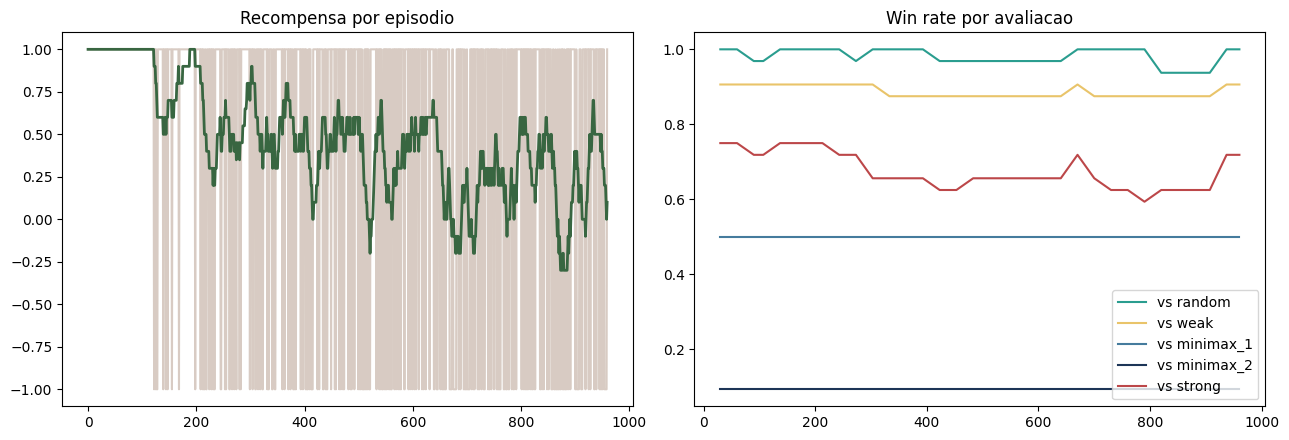

In [5]:
rewards = [float(value) for value in metrics_data.get('episode_rewards', [])]

def rolling_mean(values, window=20):
    if len(values) < window:
        return values
    return [statistics.fmean(values[max(0, idx - window + 1): idx + 1]) for idx in range(len(values))]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(rewards, color='#7f5539', alpha=0.3)
axes[0].plot(rolling_mean(rewards, 20), color='#386641', linewidth=2)
axes[0].set_title('Recompensa por episodio')

if evaluation:
    eval_x = [item['episode'] for item in evaluation]
    axes[1].plot(eval_x, [item.get('vs_random_win_rate', 0.0) for item in evaluation], label='vs random', color='#2a9d8f')
    axes[1].plot(eval_x, [item.get('vs_weak_heuristic_win_rate', 0.0) for item in evaluation], label='vs weak', color='#e9c46a')
    axes[1].plot(eval_x, [item.get('vs_minimax_1_win_rate', 0.0) for item in evaluation], label='vs minimax_1', color='#457b9d')
    axes[1].plot(eval_x, [item.get('vs_minimax_2_win_rate', 0.0) for item in evaluation], label='vs minimax_2', color='#1d3557')
    axes[1].plot(eval_x, [item.get('vs_strong_heuristic_win_rate', 0.0) for item in evaluation], label='vs strong', color='#bc4749')
    axes[1].legend()
axes[1].set_title('Win rate por avaliacao')
plt.tight_layout()
plt.show()


## Passo 6: Avaliacao final mais estavel


In [6]:
showcase_eval = {
    'vs_random': evaluate_match_summary(agent, lambda game_idx: RandomAgent(seed=10_000 + game_idx), games=120),
    'vs_weak': evaluate_match_summary(agent, lambda game_idx: WeakHeuristicAgent(seed=20_000 + game_idx), games=120),
    'vs_minimax_1': evaluate_match_summary(agent, lambda game_idx: MinimaxAgent(depth=1, seed=25_000 + game_idx), games=120),
    'vs_minimax_2': evaluate_match_summary(agent, lambda game_idx: MinimaxAgent(depth=2, seed=27_000 + game_idx), games=120),
    'vs_strong': evaluate_match_summary(agent, lambda game_idx: StrongHeuristicAgent(seed=30_000 + game_idx), games=120),
}
showcase_eval


{'vs_random': {'win_rate': 0.975,
  'draw_rate': 0.0,
  'loss_rate': 0.025,
  'mean_outcome': 0.95},
 'vs_weak': {'win_rate': 0.9083333333333333,
  'draw_rate': 0.0,
  'loss_rate': 0.09166666666666666,
  'mean_outcome': 0.8166666666666667},
 'vs_minimax_1': {'win_rate': 0.5,
  'draw_rate': 0.0,
  'loss_rate': 0.5,
  'mean_outcome': 0.0},
 'vs_minimax_2': {'win_rate': 0.1,
  'draw_rate': 0.225,
  'loss_rate': 0.675,
  'mean_outcome': -0.575},
 'vs_strong': {'win_rate': 0.75,
  'draw_rate': 0.0,
  'loss_rate': 0.25,
  'mean_outcome': 0.5}}